In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from state import BlogState
from agent import get_llm,research_agent

In [3]:
llm=get_llm()

In [4]:
llm.invoke("Hello?")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0c380-4b53-7670-8ba5-47fc14bd395e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 3, 'output_tokens': 33, 'total_tokens': 36, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 24}})

In [5]:
outline=research_agent(llm=llm,topic="what is ML?",audience="Ml engineers")

In [6]:
print(outline[:500])

Here's a research outline for "What is ML?" tailored for ML engineers:

*   **Beyond the Basics: ML as Adaptive Systems:** Reframe ML not just as algorithms, but as systems designed to learn patterns and make decisions from data without explicit programming, contrasting it with traditional software development.
    *   **Angle:** The shift from imperative to declarative programming paradigms in data-driven systems.
    *   **Keywords:** `Adaptive Systems`, `Pattern Recognition`, `Data-Driven Dec


In [7]:
from graph import build_blog_graph
from state import BlogState

# Initialize the graph
graph = build_blog_graph()
print("Graph loaded successfully!", graph)

Graph loaded successfully! <langgraph.graph.state.CompiledStateGraph object at 0x0000026B76C88D50>


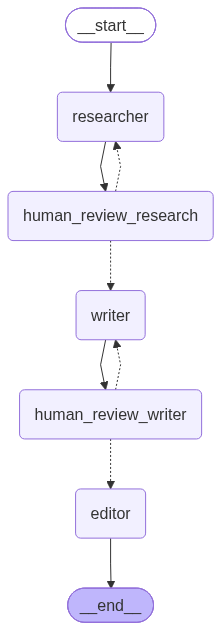

In [8]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [9]:
config={"configurable":{"thread_id":"1"}}

In [10]:
state=graph.invoke({
    "topic":"what is AI?",
    "audience":"Ai DEVLOPERS"
},
config=config
)


In [11]:
snap=graph.get_state(config)

In [12]:
interrupt_payload=snap.interrupts[0].value
interrupt_payload.get("stage")
interrupt_payload.get("research")

'Here\'s a research outline for "What is AI?" tailored for AI Developers:\n\n*   **Beyond the Buzzword: A Developer\'s Definition of AI**\n    *   **Angle:** Deconstructing the popular vs. technical understanding of AI, focusing on the underlying computational intelligence paradigms.\n    *   **Keywords:** Artificial Intelligence, Machine Learning, Deep Learning, Symbolic AI, Connectionism, Cognitive AI, Problem-solving frameworks.\n    *   **Tags:** #AIDefinition #AIParadigms #TechnicalAI\n\n*   **The Evolution of Intelligence: From Expert Systems to Foundation Models**\n    *   **Angle:** A concise historical journey highlighting key architectural shifts, paradigm changes, and "AI winters" that shaped current development practices.\n    *   **Keywords:** AI Winters, Expert Systems, Machine Learning algorithms (e.g., SVMs, Decision Trees), Neural Networks, Deep Learning architectures (e.g., CNNs, RNNs, Transformers), Foundation Models, Generative AI.\n    *   **Tags:** #AIHistory #MLE

In [14]:
from langgraph.types import Command

# Resume the graph using stream with your config
state = graph.invoke(
    Command(resume={"action": "approve", "feedback": ""}),
    config=config
)


In [15]:
state

{'topic': 'what is AI?',
 'audience': 'Ai DEVLOPERS',
 'research': 'Here\'s a research outline for "What is AI?" tailored for AI Developers:\n\n*   **Beyond the Buzzword: A Developer\'s Definition of AI**\n    *   **Angle:** Deconstructing the popular vs. technical understanding of AI, focusing on the underlying computational intelligence paradigms.\n    *   **Keywords:** Artificial Intelligence, Machine Learning, Deep Learning, Symbolic AI, Connectionism, Cognitive AI, Problem-solving frameworks.\n    *   **Tags:** #AIDefinition #AIParadigms #TechnicalAI\n\n*   **The Evolution of Intelligence: From Expert Systems to Foundation Models**\n    *   **Angle:** A concise historical journey highlighting key architectural shifts, paradigm changes, and "AI winters" that shaped current development practices.\n    *   **Keywords:** AI Winters, Expert Systems, Machine Learning algorithms (e.g., SVMs, Decision Trees), Neural Networks, Deep Learning architectures (e.g., CNNs, RNNs, Transformers), F

In [16]:
from langgraph.types import Command

# 1. Resume the graph to approve the draft (or pass feedback to revise it)
state = graph.invoke(
    Command(resume={"action": "approve", "feedback": ""}),
    config=config
)

# 2. Print out the final blog output once the editor node completes
print("=== Workflow Completed Successfully! ===")
print("Final Blog Post:\n")
print(state.get("final_blog", "Blog still processing or check state keys."))

=== Workflow Completed Successfully! ===
Final Blog Post:

Here is the polished, publication-ready blog post:

---

## Beyond the Hype: What is AI, Really? A Developer's Deep Dive

As AI developers, we stand at the epicenter of innovation. Yet, amidst the daily grind of model training, hyperparameter tuning, and deployment, it's easy for the fundamental concept of "Artificial Intelligence" to become just another buzzword. Public perception often oscillates between utopian promises and dystopian fears, but for us, it's a field of intricate computational challenges and profound potential.

This post isn't about the popular narrative; it's a technical exploration of what AI truly means, its evolutionary journey, its current state, and the ethical frontiers we must navigate. Let's peel back the layers and solidify our understanding of the intelligence we strive to build.

### Beyond the Buzzword: A Developer's Definition of AI

Forget the sci-fi robots for a moment. From a developer's pers

In [17]:
state = graph.invoke(
    Command(resume="yes"),
    config=config
)

print("Workflow resumed with 'yes'! Final Blog Output:\n")
print(state.get("final_blog"))

Workflow resumed with 'yes'! Final Blog Output:

Here is the polished, publication-ready blog post:

---

## Beyond the Hype: What is AI, Really? A Developer's Deep Dive

As AI developers, we stand at the epicenter of innovation. Yet, amidst the daily grind of model training, hyperparameter tuning, and deployment, it's easy for the fundamental concept of "Artificial Intelligence" to become just another buzzword. Public perception often oscillates between utopian promises and dystopian fears, but for us, it's a field of intricate computational challenges and profound potential.

This post isn't about the popular narrative; it's a technical exploration of what AI truly means, its evolutionary journey, its current state, and the ethical frontiers we must navigate. Let's peel back the layers and solidify our understanding of the intelligence we strive to build.

### Beyond the Buzzword: A Developer's Definition of AI

Forget the sci-fi robots for a moment. From a developer's perspective, A

In [18]:
from langgraph.types import Command

# Send feedback using a dictionary
state = graph.invoke(
    Command(resume={
        "action": "revise", 
        "feedback": "Please make the tone more professional and add a section about AI ethics."
    }),
    config=config
)

print("Workflow resumed with feedback! Current state:")
print(state)

Workflow resumed with feedback! Current state:
{'topic': 'what is AI?', 'audience': 'Ai DEVLOPERS', 'research': 'Here\'s a research outline for "What is AI?" tailored for AI Developers:\n\n*   **Beyond the Buzzword: A Developer\'s Definition of AI**\n    *   **Angle:** Deconstructing the popular vs. technical understanding of AI, focusing on the underlying computational intelligence paradigms.\n    *   **Keywords:** Artificial Intelligence, Machine Learning, Deep Learning, Symbolic AI, Connectionism, Cognitive AI, Problem-solving frameworks.\n    *   **Tags:** #AIDefinition #AIParadigms #TechnicalAI\n\n*   **The Evolution of Intelligence: From Expert Systems to Foundation Models**\n    *   **Angle:** A concise historical journey highlighting key architectural shifts, paradigm changes, and "AI winters" that shaped current development practices.\n    *   **Keywords:** AI Winters, Expert Systems, Machine Learning algorithms (e.g., SVMs, Decision Trees), Neural Networks, Deep Learning arch